# Loading pdf files and Vectorize the Conent

In [1]:
from pypdf import PdfReader
import os
from tqdm import tqdm
from pymed import PubMed
import json
import pytesseract
from pdf2image import convert_from_path

In [2]:
class PMCDocLoader:
    def __init__(self, data_dir, save_to):
        self.doc_content=[]
        self.data_dir = data_dir
        self.pubmed = PubMed(tool="MyTool", email="qzhao9@lakeheadu.ca")
        self.save_to = save_to
        self.min_words_per_line = 10
        self.pbar = None

    def get_pmc_metadata(self, pmc_ids):
        """
        Query document meta data
        """
        ids = ','.join([id.lstrip('PMC') for id in pmc_ids])
        try:
            results = self.pubmed._get("/entrez/eutils/esummary.fcgi",parameters={'db':'pmc','id':ids,'retmode':'json'})
            meta_result = results['result']
            uuids = meta_result['uids']
            metadata = {}
            for uuid in uuids:
                result = meta_result[uuid]
                authors = ', '.join([d['name'] for d in result['authors']])
                dois = [id['value'] for id in result['articleids'] if id['idtype']=='doi']
                if any(dois):
                    doi = dois[0]
                dois = '; '.join([f"{id['idtype'].upper()}:{id['value']}" for id in result['articleids']])
                cite_nlm = f"{authors}. {result['title']}. {result['source']}. {result['printpubdate']}; {result['volume']}({result['issue']}):{result['pages']}. Epub {result['epubdate']}. {dois}."
                # print(cite_nlm)
                metadata[f'PMC{uuid}'] = {
                                'id':f'PMC{uuid}',
                                'authors':authors,
                                'title': result['title'],
                                'doi':doi,
                                'cite':cite_nlm}
        except Exception as e:
            print('Failed to get meta data, error: ', e)
            return None

        return metadata


    def load(self, load_meta=True, save_output=True, limited_count=None, load_mode='pdf'):
        file_folders = os.listdir(self.data_dir)
        self.doc_content = []
        steps = 200
        file_folders = [folder for folder in file_folders if os.path.isdir(os.path.join(self.data_dir,folder))]
        
        if limited_count:
            file_folders = file_folders[:limited_count]

        self.pbar = tqdm(range(len(file_folders)))    
        load_fun = self.load_pdf_content
        if load_mode == 'ocr':
            load_fun = self.load_pdf_content_ocr

        for i in range(0, len(file_folders), steps):
            batch = file_folders[i:i+steps]
            if load_meta:
                metadata = self.get_pmc_metadata(batch)
            for folder in tqdm(batch):
                try:
                    self.pbar.set_postfix({'Doc':folder})
                    full_path = os.path.join(self.data_dir,folder)
                    files = os.listdir(full_path)
                    num_of_pdf = len([f for f in files if f.endswith('.pdf') ])
                    if num_of_pdf == 0:
                        # print(folder,'No pdf file.')
                        continue

                    nxml_file = [f for f in files if f.endswith('.nxml')]
                    if not any(nxml_file):
                        continue
                    pdf_file = nxml_file[0].replace('.nxml','.pdf')
                    ful_pdf = os.path.join(full_path,pdf_file)
                    if os.path.isfile(ful_pdf):
                        # Load Text Content
                        page_content = load_fun(ful_pdf)

                        # Load Images
                        reader = PdfReader(ful_pdf)
                        pypdf_pages = reader.pages
                        page_imgs = {}
                        for i, page in enumerate(pypdf_pages):
                            if not page.images:
                                continue
                            for img in page.images:
                                # img = img.convert("RGB")
                                img.image.save(os.path.join(full_path,img.name))
                            pil_images = [os.path.join(full_path,img.name) for img in page.images]
                            page_imgs[i] = pil_images

                        if not page_content:
                            continue
                        if load_meta:
                            meta = metadata[folder]
                        else:
                            meta = {'id':folder}
                        meta['content'] = page_content
                        meta['images'] = page_imgs
                        self.doc_content.append(meta)
                except Exception as e:
                    print('Failed to load pdf ', folder)
                    print(e)
                finally:
                    self.pbar.update(1)

        # Save extracted data
        if save_output:
            with open(self.save_to,'w+') as file:
                json.dump(self.doc_content,file)
        self.pbar.close()
        return True
    
    def load_pdf_content(self, pdf_file):
        try:
            reader = PdfReader(pdf_file)

            total_pages = len(reader.pages)
            # print('Total Pages:',total_pages)

            # print('Page 1:',page_1.extract_text())
            pages = []
            for p in range(total_pages):
                page = reader.get_page(p)
                page_content = page.extract_text(space_width=250)
                page_content, is_reference = self.post_extract_processing(page_content)
                pages.append(page_content)
                if is_reference:
                    break
        except:
            print('Failed to load ', pdf_file)
            return None

        return pages
    
    def load_pdf_content_ocr(self, pdf_file):
        """
        Read pdf text using OCR.
        """
        try:
            ocr_pages = convert_from_path(pdf_file, 600)

            # print('Pages: ', len(pages))
            # extract text
            pages_text = []
            parent_dir_name = os.path.basename(os.path.dirname(pdf_file))
            for i, p in enumerate(ocr_pages):
                self.pbar.set_postfix({'Doc':parent_dir_name,'Page':f'{i+1}/{len(ocr_pages)}'})
                page_content = pytesseract.image_to_string(p)
                page_content, is_reference = self.post_extract_process_ocr(i, page_content)
                if page_content:
                    pages_text.append(page_content)
                if is_reference:
                    break
        except Exception as e:
            print('Failed to load ', pdf_file, e)
            # raise e
            return None
        return pages_text

    def post_extract_processing(self,page_number, page_content):
        """
        Clean up extracted text
        """
        lines = page_content.split('\n')
        # print(len(lines))
        new_lines = []
        is_reference = False
        start_of_content = False
        for i in range(len(lines)):
            # print(len(lines[i]))
            if new_lines:
                line_1 = new_lines[-1]
            else:
                line_1 = ''
            line_2 = lines[i]
            if page_number == 0 and not start_of_content:
                if not self.is_start_of_text(line_2):
                    continue
                else:
                    start_of_content = True

            if self.is_reference(line_2):
                # print('is_reference: True')
                is_reference = True
                break
            last_of_line_1 = line_1[-1] if line_1 else ''
            if last_of_line_1 in ['-',',',' ',';','"'] or last_of_line_1.isalpha():
                line_1 = line_1[:-1] if line_1[-1] == '-' else line_1
                new_lines[-1] = line_1 +(' ' if last_of_line_1.isalpha else '') +  line_2
            else:
                if not self.is_ignore(line_2):
                    new_lines.append(line_2)
                else:
                    pass
        return new_lines , is_reference #Paragraph
    
    def post_extract_process_ocr(self,page_number, page_content):
        lines = page_content.split('\n')

        if page_number == 0:
            # print(page_content)
            while lines and not self.is_start_of_text(lines[0]):
                lines.pop(0)
            if not lines: # Did not match 'Abstract', then load all.
                lines = page_content.split('\n')
        paragraphs = []
        p = ''
        is_reference = False
        for line in lines:
            if self.is_reference(line):
                is_reference = True
                break
            if line:
                p += line
            elif len(p.split()) < self.min_words_per_line:
                p += ' '
            else:# a empty line is the paragraph break
                if not self.is_ignore(p):
                    paragraphs.append(p)
                p = ''
        if p:
            paragraphs.append(p)
        return paragraphs, is_reference

    def is_start_of_text(self,line):
        if line.startswith('Abstract'):
            return True
        
        return False
    
    def is_reference(self, line):
        if line.strip() == 'References':
            return True
        return False
    
    def is_ignore(self,line):
        if not line.strip():
            return True 
        if line.startswith('Acknowledgments') or\
              line.startswith('Conflicts of Interest') or\
              line.startswith('Author Contributions') or\
              line.startswith('Informed Consent Statement') or\
              line.startswith('Data Availability Statement'):
            return True
        # if len(line.strip().split()) < self.min_words_per_line:
        #     return True
        digits=[c for c in line if c.isdigit()]
        if len(digits) / len(line) >= 0.4:
            return True # Most of the charactors are numbers
        
        return False

In [ ]:
data_dir = r'/home/qzhao9/datasets/PMC-Papers/files'
metadata_file = '/home/qzhao9/datasets/metadata.jsonl'

doc_loader = PMCDocLoader(data_dir,metadata_file)

doc_loader.load(load_meta=True, save_output=True, load_mode='ocr', limited_count=0)

print(len(doc_loader.doc_content))


  2%|▏         | 35/1911 [25:50<18:50:52, 36.17s/it, Doc=PMC10651636]

Failed to load  /home/qzhao9/datasets/PMC-Papers/files/PMC9598597/antioxidants-11-01947.pdf Unable to get page count.
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't read xref table

Failed to load pdf  PMC9598597
Stream has ended unexpectedly


  5%|▍         | 88/1911 [1:07:02<22:45:30, 44.94s/it, Doc=PMC7428744, Page=12/21] Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': ['/Indexed', '/DeviceRGB', 5, IndirectObject(775, 0, 125540027573840)], '/Width': 139, '/Height': 229, '/Type': '/XObject'}
Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': ['/Indexed', '/DeviceRGB', 4, IndirectObject(777, 0, 125540027573840)], '/Width': 123, '/Height': 154, '/Type': '/XObject'}
Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': ['/Indexed', '/DeviceRGB', 5, IndirectObject(779, 0, 125540027573840)], '/Width': 62, '/Height': 121, '/Type': '/XObject'}
Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': ['/Indexed', '/DeviceRGB', 5, IndirectObject(775, 0, 125540027573840)], '/Width': 139, '/Heigh

Failed to load pdf  PMC9875997
Invalid object in /Pages


 24%|██▍       | 466/1911 [5:52:24<13:16:36, 33.08s/it, Doc=PMC6421268, Page=16/16] Multiple definitions in dictionary at byte 0x3807a for key /MediaBox
Multiple definitions in dictionary at byte 0x382b4 for key /MediaBox
Multiple definitions in dictionary at byte 0x3854e for key /MediaBox
Multiple definitions in dictionary at byte 0x3874d for key /MediaBox
Multiple definitions in dictionary at byte 0x38944 for key /MediaBox
Multiple definitions in dictionary at byte 0x38bd6 for key /MediaBox
Multiple definitions in dictionary at byte 0x38e20 for key /MediaBox
Multiple definitions in dictionary at byte 0x3908a for key /MediaBox
Multiple definitions in dictionary at byte 0x392dc for key /MediaBox
Multiple definitions in dictionary at byte 0x39546 for key /MediaBox
Multiple definitions in dictionary at byte 0x39740 for key /MediaBox
Multiple definitions in dictionary at byte 0x3998a for key /MediaBox
Multiple definitions in dictionary at byte 0x39c0c for key /MediaBox
Multiple definition

Failed to load pdf  PMC10097376
Limit reached while decompressing. 378333 bytes remaining.


 29%|██▉       | 562/1911 [7:10:19<16:20:25, 43.61s/it, Doc=PMC8329583, Page=12/12] Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': IndirectObject(343, 0, 125539513669328), '/Width': 420, '/Height': 431, '/Type': '/XObject'}
Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': IndirectObject(340, 0, 125539513669328), '/Width': 141, '/Height': 574, '/Type': '/XObject'}
Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': IndirectObject(343, 0, 125539513669328), '/Width': 420, '/Height': 431, '/Type': '/XObject'}
Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': IndirectObject(340, 0, 125539513669328), '/Width': 141, '/Height': 574, '/Type': '/XObject'}
Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent

In [26]:
id = 0
ocr_pages = doc_loader.doc_content[id]['content']
lines_p1 = ocr_pages[2]
lines_p_end = ocr_pages[-4]
print(doc_loader.doc_content[id]['id'])
for l in lines_p1:
    print(l)

print('=='*30)
if not lines_p_end:
    print('empty page')
for l in lines_p_end:
    print(l)

print(doc_loader.doc_content[id]['images'])


PMC11781193
Table 1. Primer sequences microsatellite loci. van Thieletal. | 3
Locus Chr. Motif Forward primer sequences Reverse primer sequences A 1 (TTA); AACATTGCTCCTTCAAATAATTCAG AACTTCATCCAACCGTGCAT
B 2 (AAC), TTCACCCGGTTCAAATTCA TTGTTGATAATGCAGTTGTTGCT D 2 (AAT) ACATCCGGGTGTTGAAGAAG TGGTGGATATGAATAAGCATTGA
F 4, (TAT); TGGTCGAAGTGATAATGAAGAAGA CATTCCTTATGCATCACCAAGAT J 6 (TGA)n GACTGGAAACGAAATTCATGG TTTCCCTTCAATCTCATAATCGT
K 7 (AAC), GCCGTAAGATTATGGGAAGGT GCTGAACTAACAACAGTGACATTTCTCAI 4, (CAA) ATGCCATTGAGTGGAATTGG AGTGGCTTGTGTTGGGTTTT Forward primer sequences are labeled with 6-carboxyfluorescein on the 5’-terminus.
was used for all PCR reactions, which consisted of 1 x NHg, re-action buffer, 1.5 mM MgCh, 0.04 pM dNTPs, 0.5 U BioTag (all Bio-line, Meridian Bioscience, Cincinnati, OH, USA) and 1 pmol of eachprimer (Integrated DNA Technologies, San Diego, CA, USA). Ampli-fication was performed according to the following program: 5 minat 94°C, followed by 35 cycles of 30s at 94°C, 30 

# Load documents and build vector DB

In [27]:
import json


metadata_file = '/home/qzhao9/datasets/metadata.jsonl'
with open(metadata_file,'r+') as docfile:
    content_of_docs = json.load(docfile)

print('document loaded.')


document loaded.


In [ ]:
content_of_docs[0]['content']

In [7]:
[c for c in content_of_docs[0]['content'][-2] if len(c.split()) < 10]

[]

## ChromaDB

In [ ]:
# import chromadb
# chroma_client = chromadb.PersistentClient('/home/qzhao9/datasets/chromadb')
# collection = chroma_client.get_or_create_collection(name="my_collection")


In [ ]:
doc = content_of_docs[0]
doc_id = doc['id']
ocr_pages = doc['content']
page_ids = [f'{doc_id}_P{i+1}' for i in range(len(ocr_pages))]
print(page_ids)
print(ocr_pages[0])
for pid, paragraphs in enumerate(ocr_pages):
    ids = [f'{page_ids[pid]}_{i}' for i in range(len(paragraphs))]
    print(ids)

['PMC11781193_P1', 'PMC11781193_P2', 'PMC11781193_P3', 'PMC11781193_P4', 'PMC11781193_P5', 'PMC11781193_P6', 'PMC11781193_P7', 'PMC11781193_P8', 'PMC11781193_P9']
['Isabelle A.M. van Thiel ©1223," Irini A.M. Kreulen ©23 T Mélanie V. Bénard ©3414, Marcus C. de Goffau O25 Bart Theelen 1, Sigrid  E.M. Heinsbroek ©2234 Patrycja K. Zylka\', Cyriel Y. Ponsioen ©. Teun Boekhout 1, Wouter J. de Jonge ©2346 Sgren Rosendahl o7', 'tWesterdijk Fungal Biodiversity Institute, Royal Dutch Academy of Arts and Sciences, Uppsalalaan 8, 3584 CT Utrecht, The Netherlands  *Tytgat Institute for Liver and Intestinal Research, Amsterdam University Medical Centers, Location Academic Medical Center (AMC), Meibergdreef 69-71, 1105 BK Amsterdam, The Netherlands  >Amsterdam UMC, University of Amsterdam, Amsterdam Gastroenterology Endocrinology Metabolism, Meibergdreef 9, 1105 AZ Amsterdam, The Netherlands “Department of Gastroenterology and Hepatology, Amsterdam University Medical Centers, Location Academic Medica

## documents

In [28]:
import chromadb
from chromadb.utils.data_loaders import ImageLoader
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction

client = chromadb.PersistentClient('/home/qzhao9/datasets/chromadb')

data_loader = ImageLoader()
embedding_function = OpenCLIPEmbeddingFunction()

coll_name='multimodal_collection'
client.delete_collection(name=coll_name)
collection = client.get_or_create_collection(
    name=coll_name,
    embedding_function=embedding_function,
    data_loader=data_loader
)

In [32]:
from tqdm import tqdm

pbar = tqdm(content_of_docs[:], desc='Update collection')
for doc in pbar:
    doc_id = doc['id']
    ocr_pages = doc['content']
    images = doc['images']
    page_ids = [f'{doc_id}_P{i+1}' for i in range(len(ocr_pages))]
    pbar.set_postfix_str('Add Documents')
    for pid, paragraphs in enumerate(ocr_pages):
        ids = [f'{page_ids[pid]}_{i}' for i in range(len(paragraphs))]
        metadatas=[{'title':doc['title'],'page':pid,'cite':doc['cite']} for i in range(len(paragraphs))]
        collection.add(
            ids=ids,
            documents=paragraphs,
            metadatas=metadatas
        )
    pbar.set_postfix_str('Add Images')
    for key, vals in images.items():
       ids=[f'{doc_id}_IP{key}_{i}' for i in range(len(vals))]
       collection.add(
            ids=ids,
            uris=vals
        )


# def load_image(uri):
#     img = Image.open(uri)
#     img_np = np.array(img, dtype=np.uint8, copy=True)
#     return img_np

# collection.add(
#     ids=["id1", "id2"],
#     images=[load_image("/home/qzhao9/datasets/kvasir-dataset/polyps/0a874a44-90ea-42ea-a467-92a1d3a4a26c.jpg"), 
#           load_image("/home/qzhao9/datasets/kvasir-dataset/ulcerative-colitis/6acfb44a-2b22-4d49-a3bf-9ffc2461c3f9.jpg")]
# )

# # collection.add(
# #     ids=["id3", "id4"],
# #     documents=["This is a polyp image", "This is a UC image"]
# # )


Update collection: 100%|██████████| 1/1 [00:24<00:00, 24.12s/it, Add Images]


In [33]:
print(client.heartbeat())
print(collection.count())

1766118969828777337
83


In [ ]:
content_of_docs[2]['content'][0]

In [45]:
results = collection.query( query_texts='nodes of graph', 
                        #    query_uris=['/home/qzhao9/datasets/PMC-Papers/files/PMC11781193/Im1.jpg'],
                            n_results=10)
print(results['documents'])
print(results['ids'])
print(results['metadatas'])
print(results['distances'])

[['SS DISTANCE Samples/Node (D) (E) PC1 PC2* * * * * KOK OK1.0 —— srt_ 1.0 eaeOk OK OK0.5O 0.5 x C7 2 oo4- fo...-0.5Cee reCD UC HV CD UC HV(6) pct 3c*0.8 0.50.051: Peete cere eee— 0.4 ~a 90.2-0.5Glee', 'Data availability Medical data will not be made available due to privacy regulations.Data generated in this study are available in the SupplementaryMaterials.', 'Received 25 September 2024; revised 14 November 2024; accepted 9 January 2025', 'Oo FN DON N © Ys“NNCwto— NJ—" CO Pr—2S 1.50 (1.60)', '©ror) Activity (1 - Pz)SoiN ©No 0.0 10050 CD UC HV', 'Proteinase Activity (1 - Pz)o os fs 9°NO . oO oo', '© The Author(s) 2025. Published by Oxford University Press on behalf of FEMS. This is an Open Access article distributed under the terms of the CreativeCommons Attribution-NonCommercial-NoDerivs licence (https://creativecommons.org/licenses/by-nc-nd/4.0/), which permits non-commercial reproductionand distribution of the work, in any medium, provided the original work is not altered or transf

In [36]:
results

{'ids': [['PMC11781193_P1_0',
   'PMC11781193_P1_1',
   'PMC11781193_P4_6',
   'PMC11781193_P6_9',
   'PMC11781193_P4_2',
   'PMC11781193_P1_3',
   'PMC11781193_P4_1',
   'PMC11781193_P6_3',
   'PMC11781193_P1_4',
   'PMC11781193_P9_3']],
 'embeddings': None,
 'documents': [['Abstract Inflammatory diseases of the human gastrointestinal tract are affected by the microbes that reside in the mucosal surfaces. Pa-tients with inflammatory bowel diseases (IBD) have altered bacterial and fungal intestinal compositions, including higher levels offecal Candida yeasts. Ongoing research indicates that genetic and phenotypic diversity of Candida albicans may be linked with diseaseseverity. Here, we set out to investigate feces-derived C. albicans strains from individuals with IBD and healthy volunteers throughmicrosatellite-based genotyping and phenotypic assays. A seven-locus microsatellite panel was applied, of which six loci were newlydeveloped. It appears that there is no specific lineage of C

# Build FAISS index

In [ ]:
# from sentence_transformers import SentenceTransformer
# import faiss
# import numpy as np

# # 1. Load embedding model
# embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

# # 2. Compute embeddings
# embeddings = embedder.encode(corpus[:3297], convert_to_numpy=True, show_progress_bar=True)
# print('Done computing embeddings')
# # 3. Build FAISS index
# dimension = embeddings.shape[1]
# print('dimension=',dimension)
# index = faiss.IndexFlatL2(dimension)
# index.add(embeddings)
# print('Done adding embeddings to index')


In [ ]:
def pico_prompt(question):
    template = f"""
You are a clinical evidence extraction assistant.
Rewrite the following medical question into structured PICO format:

P: Patient / Population  
I: Intervention  
C: Comparison  
O: Outcome  

Question: {question}

Return only structured PICO elements.
"""
    return template


def retrieve_top_k(pico_query, k=3):
    q_emb = embedder.encode([pico_query], convert_to_numpy=True)
    distances, indices = index.search(q_emb, k)
    
    retrieved = [corpus[i] for i in indices[0]]
    return retrieved

def medical_rag_qa(question,generator):
    # Step 1 — Convert to PICO
    pico_query = pico_prompt(question)

    # Step 2 — Retrieve evidence
    retrieved = retrieve_top_k(pico_query, k=3)
    context = "\n".join(retrieved)
    print('Context:', context)
    # Step 3 — Construct final answer prompt
    final_prompt = f"""
You are a medical expert. Use ONLY the evidence provided.

=== Evidence ===
{context}

=== Question ===
{question}

Provide:
1. A concise medical answer
2. A rationale referencing the evidence
3. Confidence level (low / medium / high)
"""

    # Step 4 — Generate final answer
    result = generator(question=question,     
                       context='context')
    answer = result['answer']
    print(result['score'])
    return answer



In [ ]:
from transformers import pipeline, AutoTokenizer

# tokenizer = AutoTokenizer.from_pretrained(
#     "distilbert-base-cased-distilled-squad",
#     use_fast=True
# )

generator = pipeline("question-answering", 
                        model='distilbert-base-cased-distilled-squad', 
                        # tokenizer=tokenizer,
                        # use_fast=True
                        )

In [ ]:
print(type(generator.tokenizer))
print(generator.tokenizer.is_fast)
print(type(generator.model))

import transformers
import inspect

print(transformers.__version__)
print(inspect.getfile(transformers))



In [ ]:
generator(question="What is a good example of a question answering dataset?",  context='Peter the cat is a good example')

In [ ]:
question = """
A few non-lift polyps were found in a 55-year-old patient. What could be the problem?
"""

print(medical_rag_qa(question, generator))


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch, json

model_name='Qwen/Qwen2.5-1.5B-Instruct'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)



In [ ]:
def pico_query(user_query):
    prompt = pico_prompt(user_query)
    inputs = tokenizer(prompt, return_tensors="pt")
    tokens = model.generate(**inputs, max_length=512)
    output = tokenizer.decode(tokens[0], skip_special_tokens=True)
    return output #json.loads(output[output.find("{"):output.rfind("}")+1])

In [ ]:
pico_query(question)

In [ ]:
# meta = reader.metadata

# # All the following could be None!
# print('Title:',meta.title)
# print('Author:',meta.author)
# print('Subject:',meta.subject)
# print('keywords:',meta.keywords)
# # print(meta.producer)
# print('Created On:',meta.creation_date)
# print(meta.modification_date)

# pdfplumber


Im1.jpg {'/BitsPerComponent': 8, '/ColorSpace': '/DeviceRGB', '/Filter': '/DCTDecode', '/Height': 792, '/Subtype': '/Image', '/Type': '/XObject', '/Width': 802}


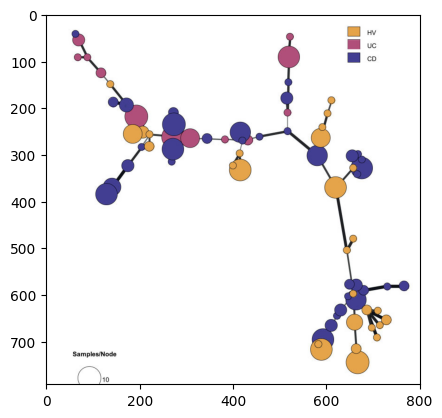

Im2.jpg {'/BitsPerComponent': 8, '/ColorSpace': '/DeviceRGB', '/Filter': '/DCTDecode', '/Height': 200, '/Subtype': '/Image', '/Type': '/XObject', '/Width': 199}


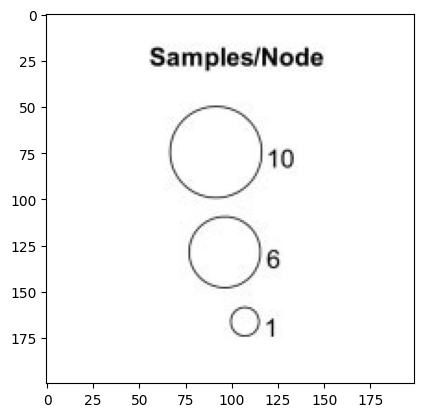

Im3.png {'/BitsPerComponent': 8, '/ColorSpace': '/DeviceRGB', '/Filter': '/FlateDecode', '/Height': 107, '/Subtype': '/Image', '/Type': '/XObject', '/Width': 508}


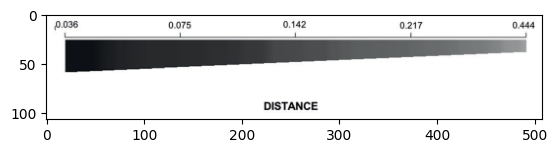

In [21]:
import pdfplumber
import os
from matplotlib import pyplot as plt

pdf_file = '/home/qzhao9/datasets/PMC-Papers/files/PMC11781193/ftaf001.pdf'
print()
# with pdfplumber.open(pdf_file) as pdf:
#     first_page = pdf.pages[1]
#     text = first_page.extract_text(space_width=200)
#     table = first_page.extract_table()
#     image = first_page.images
#     print(text) 
#     print(table)
#     print(image)

from pypdf import PdfReader

reader = PdfReader(pdf_file)
for page in reader.pages:
  if page.images:
    for image in page.images:
      print(image.name, image.indirect_reference)
      image.image.save('/home/qzhao9/datasets/PMC-Papers/files/PMC11781193/'+image.name)
      plt.imshow(image.image)
      plt.show()
# print(page.extract_text(space_width=200))

# doc_loader.load_pdf_content_ocr(pdf_file)





In [ ]:
ocr_pages = convert_from_path(pdf_file, 600)
print('Pages: ', len(ocr_pages))
# extract text
ocr_pages = []
for p in ocr_pages:
    page_content = pytesseract.image_to_string(p)
    print('Extracted :',len(page_content))
    page_content, is_reference = doc_loader.post_extract_processing(page_content)
    ocr_pages.append(page_content)
    if is_reference:
        break


In [ ]:
ocr_pages

In [ ]:
text_data.split('\n')

# "unstructured[all-docs]"

In [ ]:
# from unstructured.partition.auto import partition
# blocks = partition(filename=pdf_file)
# for block in blocks:
#     print(f"{block.category}: {block.text}")